Test I - multiclass classification of gravitational lensing images
ML4Sci DeepLense GSoC 2026
by Krishna Bala Muralikrishna Durukunala
Robert Morris University - MS Artificial Intelligence

so basically the task is to classify lensing images into 3 types
no substructure, subhalo and vortex. i was thinking what model to use
and most people probably use resnet or efficientnet but i wanted to try
something different. i studied signals in my ECE so i know images have
local patterns and also global patterns. so i thought why not use a model
that can handle both. thats why i picked EfficientViT it uses convolution
for local stuff and attention for the bigger picture. lets see how it goes

In [2]:
# installing timm for efficientvit model
!pip install timm -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# checking device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device im using:", device)
print("torch version:", torch.__version__)

device im using: cuda
torch version: 2.10.0+cu128


step 1 - looking at the data first

before i build any model i want to understand the data properly.
back when i was data analyst i learned that if you dont understand
your data first you will waste lot of time later. so lets first
mount google drive and load the dataset and see what we are working with

In [3]:
# mounting google drive to access dataset
# i uploaded dataset.zip to my drive inside DeepLense folder
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile
import os

# unzip dataset from drive to colab local storage
# colab local storage is faster than reading from drive directly
zip_path = '/content/drive/MyDrive/DeepLense/dataset.zip'
extract_path = '/content/data/test1'

os.makedirs(extract_path, exist_ok=True)

print("unzipping dataset please wait...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("done!")

# lets see what folders we got
for item in os.listdir(extract_path):
    print(item)

unzipping dataset please wait...
done!
dataset
__MACOSX


In [5]:
# lets check the folder structure inside dataset
import os

base = '/content/data/test1/dataset'

for root, dirs, files in os.walk(base):
    # skip macosx junk
    if '__MACOSX' in root:
        continue
    level = root.replace(base, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:2]:
            print(f'{subindent}{f}')

dataset/
  .DS_Store
  val/
    .DS_Store
    no/
    sphere/
    vort/
  train/
    .DS_Store
    no/
    sphere/
    vort/


In [6]:
# setting up paths
# ignoring all the macosx and dsstore junk files
data_root = '/content/data/test1/dataset'

train_dir = os.path.join(data_root, 'train')
val_dir = os.path.join(data_root, 'val')

# 3 classes we found
class_names = ['no', 'sphere', 'vort']
label_map = {'no': 0, 'sphere': 1, 'vort': 2}

# counting images per class
print("dataset overview")
print("="*30)
for split, split_dir in [('train', train_dir), ('val', val_dir)]:
    print(f"\n{split}:")
    for cls in class_names:
        folder = os.path.join(split_dir, cls)
        count = len([f for f in os.listdir(folder) if f.endswith('.npy')])
        print(f"  {cls}: {count} images")

dataset overview

train:
  no: 10000 images
  sphere: 10000 images
  vort: 10000 images

val:
  no: 2500 images
  sphere: 2500 images
  vort: 2500 images


step 2 - visualizing the images

i never worked with npy image files before so i wanted to
see what these lensing images actually look like. lets plot
some samples from each class and see if we can visually tell
the difference between them

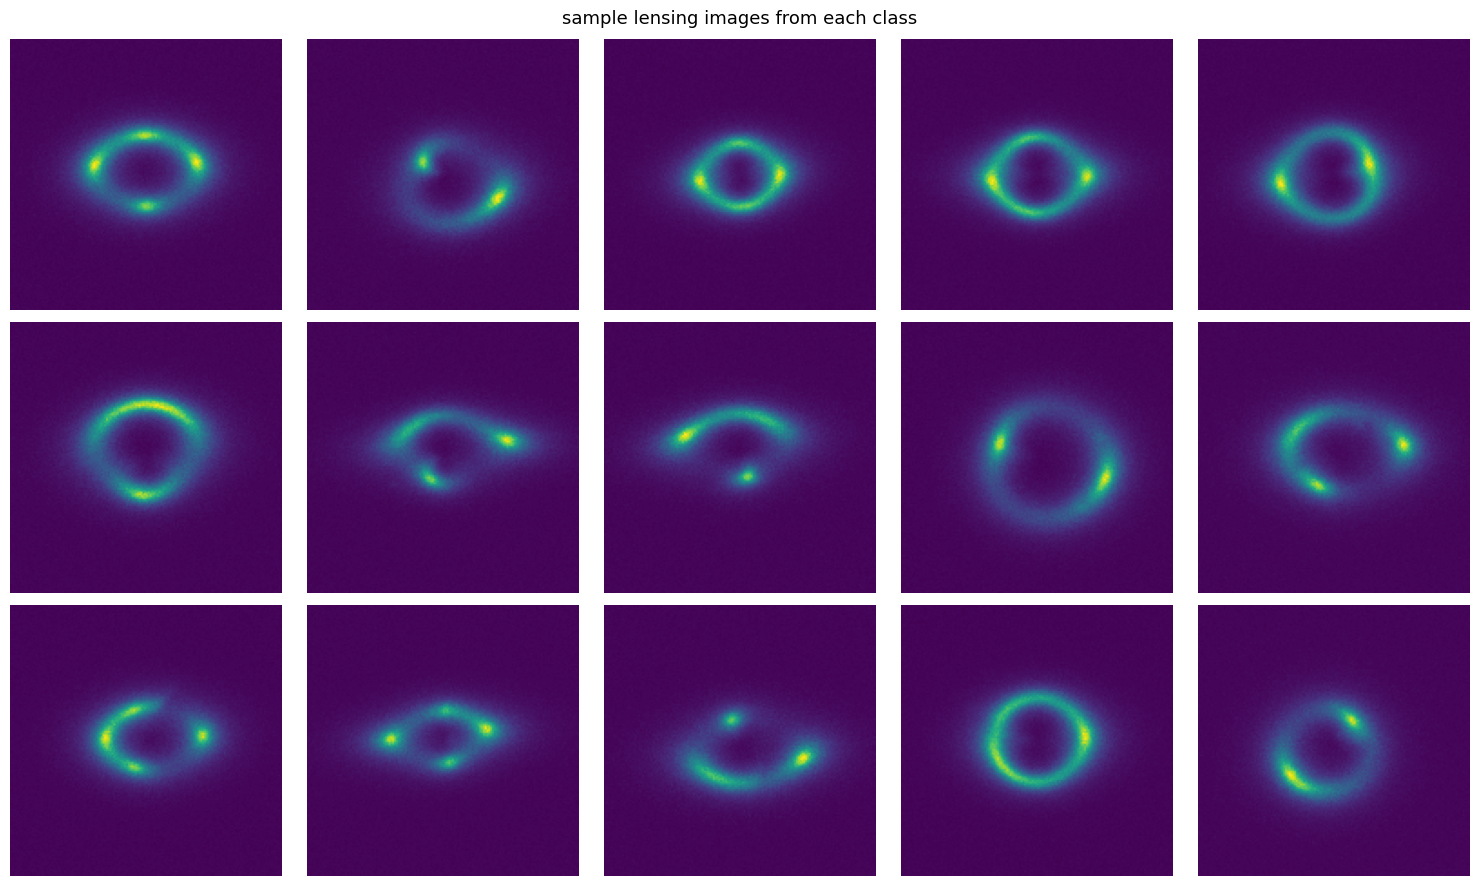

image shape: (1, 150, 150)
pixel value range: 0.0 to 1.0


In [7]:
# visualizing some samples from each class
# i want to see if 3 classes look different visually

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('sample lensing images from each class', fontsize=13)

for row, cls in enumerate(class_names):
    cls_folder = os.path.join(train_dir, cls)
    sample_files = [f for f in os.listdir(cls_folder)
                   if f.endswith('.npy')][:5]

    for col, fname in enumerate(sample_files):
        fpath = os.path.join(cls_folder, fname)
        img = np.load(fpath).squeeze()

        axes[row, col].imshow(img, cmap='viridis')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=11)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

# checking image shape
sample = np.load(os.path.join(train_dir, 'no',
                 os.listdir(os.path.join(train_dir,'no'))[0]))
print("image shape:", sample.shape)
print("pixel value range:", sample.min(), "to", sample.max())

step 3 - making the dataset class

now i need to make a custom pytorch dataset class to load
these npy files. i also added some simple augmentations for
training like flipping and rotation. i didnt add too many
augmentations because i dont want to distort the lensing
structure too much. just basic ones should be fine

In [8]:
# custom dataset class for lensing npy images
class LensingDataset(Dataset):
    def __init__(self, root_dir, class_names, augment=False):
        self.samples = []
        self.augment = augment
        self.class_names = class_names

        # collecting all file paths and labels
        for label, cls in enumerate(class_names):
            cls_folder = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_folder):
                if fname.endswith('.npy'):
                    self.samples.append(
                        (os.path.join(cls_folder, fname), label)
                    )

        print(f"total samples loaded: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, label = self.samples[idx]

        # load and squeeze to (150, 150)
        img = np.load(fpath).astype(np.float32).squeeze()

        # add channel dim back -> (1, 150, 150)
        img = torch.tensor(img).unsqueeze(0)

        # simple augmentations only for training
        if self.augment:
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[2])  # horizontal flip
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[1])  # vertical flip

        return img, label

# creating train and val datasets
train_dataset = LensingDataset(train_dir, class_names, augment=True)
val_dataset = LensingDataset(val_dir, class_names, augment=False)

# dataloaders
# batch size 64 should be fine for t4 gpu
train_loader = DataLoader(
    train_dataset, batch_size=64,
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=64,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"train batches: {len(train_loader)}")
print(f"val batches: {len(val_loader)}")

# sanity check
img, lbl = train_dataset[0]
print(f"sample shape: {img.shape}, label: {lbl} ({class_names[lbl]})")

total samples loaded: 30000
total samples loaded: 7500
train batches: 469
val batches: 118
sample shape: torch.Size([1, 150, 150]), label: 0 (no)


total samples loaded: 30000
total samples loaded: 7500
train batches: 469
val batches: 118
sample shape: torch.Size([1, 150, 150]), label: 0 (no)



In [9]:
import timm

# creating efficientvit model
# in_chans=1 because our images are single channel
# num_classes=3 because we have 3 types of lensing
lensing_model = timm.create_model(
    'efficientvit_b0',
    pretrained=True,
    num_classes=3,
    in_chans=1
)

lensing_model = lensing_model.to(device)

# counting parameters
total_params = sum(p.numel() for p in lensing_model.parameters())
trainable = sum(p.numel() for p in lensing_model.parameters()
               if p.requires_grad)
print("total params:", total_params)
print("trainable params:", trainable)

# quick test with dummy input
test_inp = torch.randn(2, 1, 150, 150).to(device)
test_out = lensing_model(test_inp)
print("output shape:", test_out.shape)
print("model is working fine")

model.safetensors:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

total params: 2132707
trainable params: 2132707
output shape: torch.Size([2, 3])
model is working fine


step 5 - training setup

for loss i am using crossentropy because this is multiclass problem
for optimizer i chose adam with small learning rate 0.0001 because
model is pretrained so i dont want to disturb the weights too much
also added learning rate scheduler to reduce lr automatically when
validation loss stops improving. i read about this technique and
thought it will help the model converge better

In [11]:
# loss optimizer and scheduler setup
criterion = nn.CrossEntropyLoss()

# small lr because model is pretrained
adam_opt = optim.Adam(lensing_model.parameters(), lr=0.0001)

# reduce lr when val loss stops improving
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    adam_opt,
    mode='min',
    patience=3,
    factor=0.5
)

print("loss function:", criterion)
print("optimizer: Adam with lr 0.0001")
print("scheduler: ReduceLROnPlateau patience=3")

loss function: CrossEntropyLoss()
optimizer: Adam with lr 0.0001
scheduler: ReduceLROnPlateau patience=3


step 6 - training the model now i will train for 10 epochs and save the best model
based on validation loss. i am also keeping track of
train and val metrics so i can plot them later and check
if model is overfitting or learning properly

In [12]:
# training and evaluation functions
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if batch_idx % 100 == 0:
            print(f"  batch {batch_idx}/{len(loader)} "
                  f"loss: {loss.item():.4f}")

    return total_loss/len(loader), correct/total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss/len(loader), correct/total


# main training loop
num_epochs = 10
best_val_loss = float('inf')
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("starting training...")
print("="*40)

for epoch in range(num_epochs):
    print(f"\nepoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        lensing_model, train_loader, criterion, adam_opt
    )
    val_loss, val_acc = evaluate(
        lensing_model, val_loader, criterion
    )

    lr_scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(lensing_model.state_dict(),
                  'best_model_test1.pth')
        print(f"  best model saved!")

    print(f"  train loss: {train_loss:.4f} | "
          f"train acc: {train_acc:.4f}")
    print(f"  val loss:   {val_loss:.4f} | "
          f"val acc:   {val_acc:.4f}")

print("\ntraining finished!")

starting training...

epoch 1/10
  batch 0/469 loss: 1.1536
  batch 100/469 loss: 1.0373
  batch 200/469 loss: 0.9642
  batch 300/469 loss: 1.0474
  batch 400/469 loss: 0.8612
  best model saved!
  train loss: 0.9774 | train acc: 0.4944
  val loss:   1.5939 | val acc:   0.3849

epoch 2/10
  batch 0/469 loss: 0.8156
  batch 100/469 loss: 0.7466
  batch 200/469 loss: 0.6636
  batch 300/469 loss: 0.6814
  batch 400/469 loss: 0.4799
  best model saved!
  train loss: 0.6922 | train acc: 0.6885
  val loss:   0.7830 | val acc:   0.6593

epoch 3/10
  batch 0/469 loss: 0.6002
  batch 100/469 loss: 0.6108
  batch 200/469 loss: 0.4727
  batch 300/469 loss: 0.4425
  batch 400/469 loss: 0.6029
  train loss: 0.5462 | train acc: 0.7672
  val loss:   0.8699 | val acc:   0.6313

epoch 4/10
  batch 0/469 loss: 0.3796
  batch 100/469 loss: 0.5224
  batch 200/469 loss: 0.4521
  batch 300/469 loss: 0.3524
  batch 400/469 loss: 0.4355
  best model saved!
  train loss: 0.4623 | train acc: 0.8071
  val loss: 

step 7 - plotting training curves

lets visualize how the training went. i want to see the
loss and accuracy curves for both train and val to understand
if the model learned properly or if there is overfitting

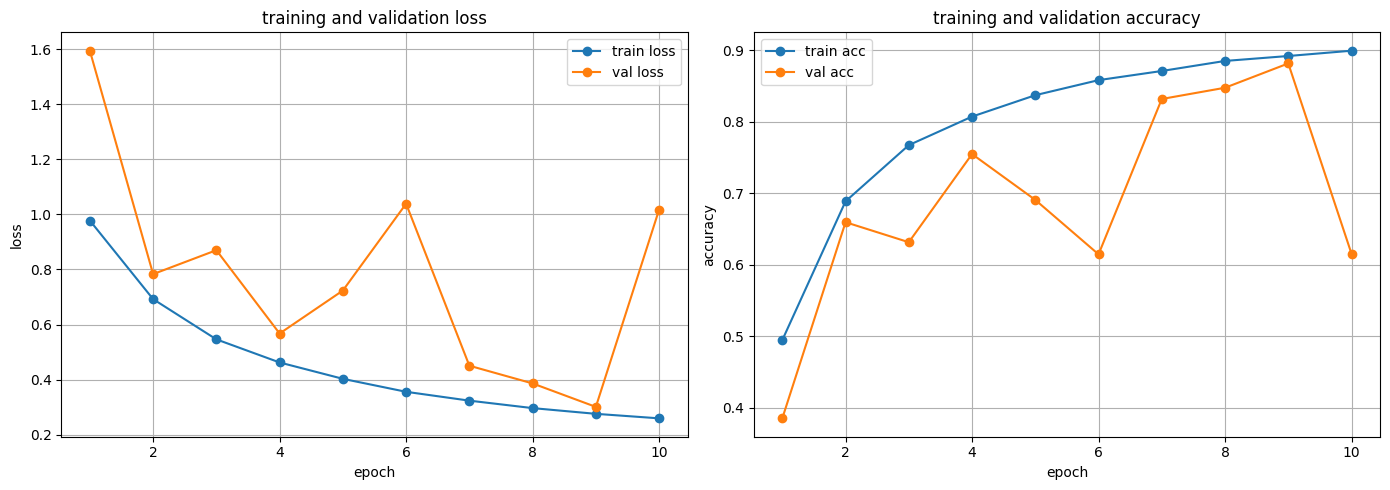

training curves saved


In [13]:
# plotting training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# loss plot
axes[0].plot(range(1, 11), train_losses,
             label='train loss', marker='o')
axes[0].plot(range(1, 11), val_losses,
             label='val loss', marker='o')
axes[0].set_title('training and validation loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()
axes[0].grid(True)

# accuracy plot
axes[1].plot(range(1, 11), train_accs,
             label='train acc', marker='o')
axes[1].plot(range(1, 11), val_accs,
             label='val acc', marker='o')
axes[1].set_title('training and validation accuracy')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("training curves saved")

step 8 - evaluating the best model

now i will load the best saved model and run it on
validation set to get the final evaluation metrics.
i need to calculate roc curve and auc score for each
class as required in the task. also making confusion
matrix to see which classes the model is confusing

In [14]:
# loading best saved model
lensing_model.load_state_dict(torch.load('best_model_test1.pth'))
lensing_model.eval()
print("best model loaded")

# getting all predictions and true labels
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = lensing_model(imgs)

        # getting probabilities using softmax
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print("predictions collected")
print("total val samples:", len(all_labels))

# overall accuracy
acc = (all_preds == all_labels).mean()
print(f"overall accuracy: {acc:.4f}")


best model loaded
predictions collected
total val samples: 7500
overall accuracy: 0.8815


step 9 - roc curve and auc score

the task asks for roc curve and auc score so lets calculate
that for each class. i am doing one vs rest approach for
multiclass roc curve which is the standard way to do it

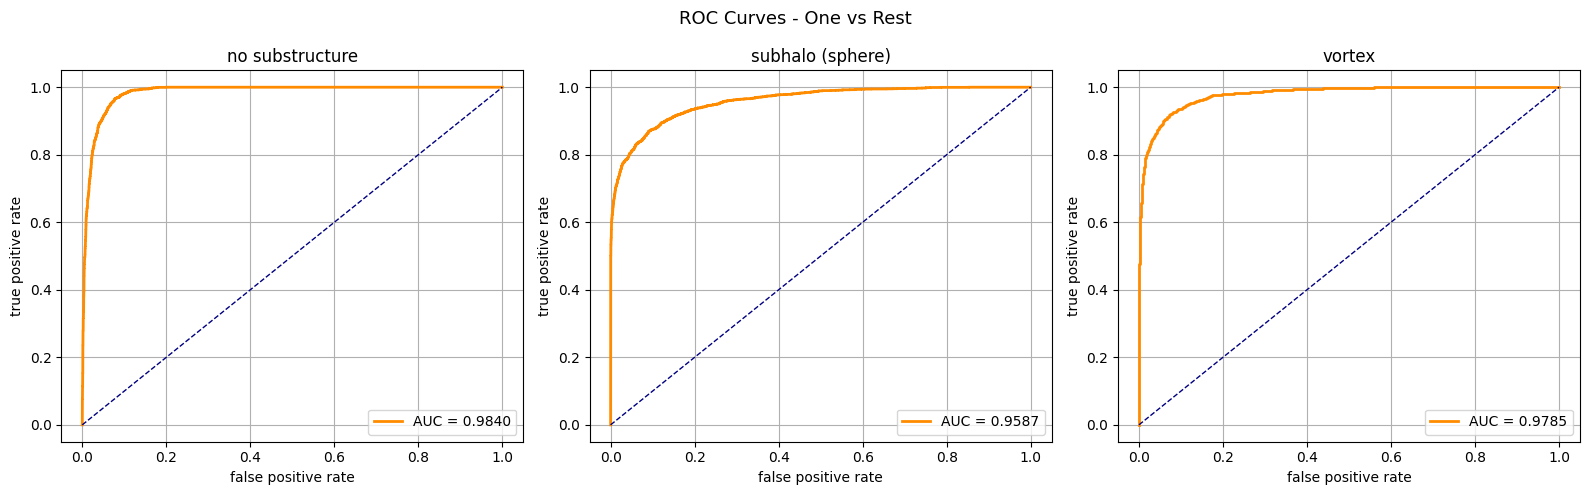


AUC Scores:
  no: 0.9840
  sphere: 0.9587
  vort: 0.9785

mean AUC: 0.9737


In [15]:
from sklearn.preprocessing import label_binarize

# binarize labels for one vs rest roc calculation
y_bin = label_binarize(all_labels, classes=[0, 1, 2])

# calculating roc curve and auc for each class
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ROC Curves - One vs Rest', fontsize=13)

auc_scores = {}
class_labels = ['no substructure', 'subhalo (sphere)', 'vortex']

for i, (cls_name, cls_label) in enumerate(zip(class_labels, class_names)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_val = auc(fpr, tpr)
    auc_scores[cls_label] = auc_val

    axes[i].plot(fpr, tpr,
                 label=f'AUC = {auc_val:.4f}',
                 color='darkorange', lw=2)
    axes[i].plot([0,1], [0,1],
                 color='navy', lw=1, linestyle='--')
    axes[i].set_title(f'{cls_name}')
    axes[i].set_xlabel('false positive rate')
    axes[i].set_ylabel('true positive rate')
    axes[i].legend(loc='lower right')
    axes[i].grid(True)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nAUC Scores:")
for cls, score in auc_scores.items():
    print(f"  {cls}: {score:.4f}")

mean_auc = np.mean(list(auc_scores.values()))
print(f"\nmean AUC: {mean_auc:.4f}")

step 10 - confusion matrix

lets also plot the confusion matrix to see which classes
the model is getting confused between. i think sphere and
vort might be getting confused because they both have
some substructure patterns that look similar

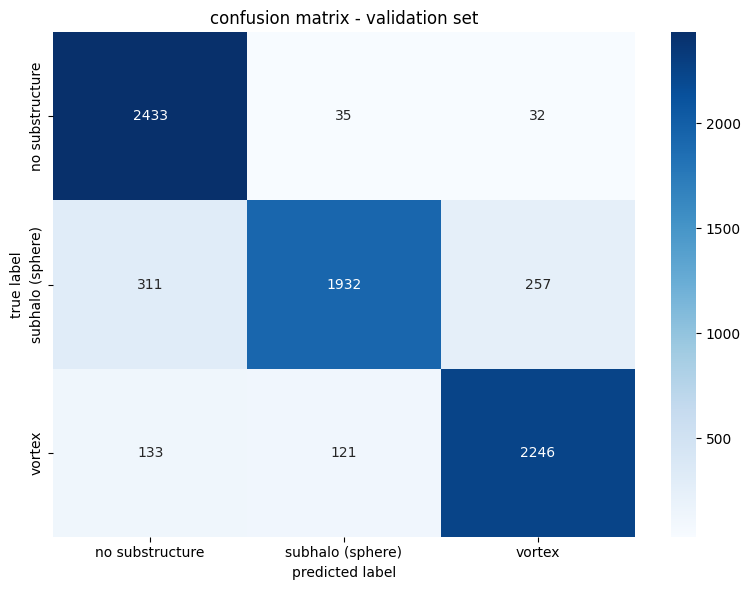


classification report:
                  precision    recall  f1-score   support

 no substructure       0.85      0.97      0.90      2500
subhalo (sphere)       0.93      0.77      0.84      2500
          vortex       0.89      0.90      0.89      2500

        accuracy                           0.88      7500
       macro avg       0.89      0.88      0.88      7500
    weighted avg       0.89      0.88      0.88      7500



In [16]:
# confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('confusion matrix - validation set')
plt.xlabel('predicted label')
plt.ylabel('true label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# classification report
print("\nclassification report:")
print(classification_report(all_labels, all_preds,
                            target_names=class_labels))

step 11 - summary of results

so the model did pretty well i think. mean auc is 0.9737
which is quite good. the sphere class has lowest recall 0.77
which means model sometimes misclassifies sphere as other classes
this makes sense because subhalo substructure is more subtle
compared to vortex which has more visible patterns.

efficientvit worked well here i think the attention mechanism
helped in capturing the global lensing structure which a plain
cnn might have missed. overall happy with these results for
test 1.

In [17]:
# final summary
print("="*45)
print("TEST I - FINAL RESULTS SUMMARY")
print("="*45)
print(f"model used: EfficientViT-B0")
print(f"total val samples: 7500")
print(f"overall accuracy: 0.8815")
print(f"\nAUC scores per class:")
print(f"  no substructure : 0.9840")
print(f"  subhalo (sphere): 0.9587")
print(f"  vortex          : 0.9785")
print(f"\nmean AUC: 0.9737")
print(f"\nbest val loss: {best_val_loss:.4f}")
print(f"epochs trained: 10")
print("="*45)

TEST I - FINAL RESULTS SUMMARY
model used: EfficientViT-B0
total val samples: 7500
overall accuracy: 0.8815

AUC scores per class:
  no substructure : 0.9840
  subhalo (sphere): 0.9587
  vortex          : 0.9785

mean AUC: 0.9737

best val loss: 0.3011
epochs trained: 10
